# Model Comparison

This notebook compares Model A and Model B on the shared holdout split using Accuracy, F1, and ROC-AUC.

In [4]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from PIL import Image
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms

In [5]:
# Locate the project root directory.
def find_root():
    cwd = Path.cwd().resolve()
    for root in [cwd, *cwd.parents]:
        if (root / "notebooks").exists() and (root / "requirements.txt").exists():
            return root
    for root in [Path("/content/OCT-SRGAN"), Path("/content/drive/MyDrive/OCT-SRGAN")]:
        if root.exists():
            return root
    return cwd

root_dir = find_root()
split_dir = root_dir / "artifacts" / "splits"
test_csv = split_dir / "test_split.csv"
if not test_csv.exists():
    raise FileNotFoundError("Missing test split CSV at: " + str(test_csv))
test_df = pd.read_csv(test_csv)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

img_size = 128
batch_size = 32
worker_n = 2

# Dataset for evaluation samples.
class EvalSet(Dataset):
    # Initialize class state.
    def __init__(self, data_df):
        self.data_df = data_df.reset_index(drop=True)
        self.eval_tf = transforms.Compose(
            [
                transforms.Resize((img_size, img_size), interpolation=transforms.InterpolationMode.BICUBIC),
                transforms.ToTensor(),
                transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
            ]
        )

    # Return the dataset size.
    def __len__(self):
        return len(self.data_df)

    # Return a single sample.
    def __getitem__(self, idx):
        row = self.data_df.iloc[idx]
        img = Image.open(row["path"]).convert("RGB")
        img_x = self.eval_tf(img)
        img_y = torch.tensor(float(row["bin_label"]), dtype=torch.float32)
        return img_x, img_y

test_set = EvalSet(test_df)
test_loader = DataLoader(
    test_set,
    batch_size=batch_size,
    shuffle=False,
    num_workers=worker_n,
    pin_memory=True,
)

# Build the VGG16 binary classifier.
def build_vgg():
    net = models.vgg16(weights=None)
    for param in net.features[:-8].parameters():
        param.requires_grad = False
    net.classifier = nn.Sequential(
        nn.Linear(25088, 1024),
        nn.ReLU(inplace=True),
        nn.Dropout(0.4),
        nn.Linear(1024, 256),
        nn.ReLU(inplace=True),
        nn.Dropout(0.3),
        nn.Linear(256, 1),
    )
    return net

row_list = []
for model_id in ["model_a", "model_b"]:
    ckpt = root_dir / "checkpoints" / model_id / f"{model_id}_final.pth"
    if ckpt.exists():
        net = build_vgg().to(device)
        net.load_state_dict(torch.load(ckpt, map_location=device))
        net.eval()
        prob_all, lab_all = [], []
        with torch.no_grad():
            for img_x, img_y in test_loader:
                img_x = img_x.to(device, non_blocking=True)
                logits = net(img_x)
                prob_all.append(torch.sigmoid(logits).cpu().numpy().ravel())
                lab_all.append(img_y.numpy().ravel())
        y_prob = np.concatenate(prob_all)
        y_true = np.concatenate(lab_all).astype(int)
        y_pred = (y_prob >= 0.5).astype(int)
        score = {
            "model": "Model A" if model_id == "model_a" else "Model B",
            "accuracy": float(accuracy_score(y_true, y_pred)),
            "f1": float(f1_score(y_true, y_pred)),
            "auc": float(roc_auc_score(y_true, y_prob)),
        }
    else:
        score = {
            "model": "Model A" if model_id == "model_a" else "Model B",
            "accuracy": None,
            "f1": None,
            "auc": None,
        }
        print(f"Checkpoint not found for {model_id}: {ckpt}")
    row_list.append(score)

comp_df = pd.DataFrame(row_list).set_index("model")
comp_df

,accuracy,f1,auc
model,,,
Model A,0.981443,0.983302,0.999455
Model B,0.988660,0.989899,0.998400


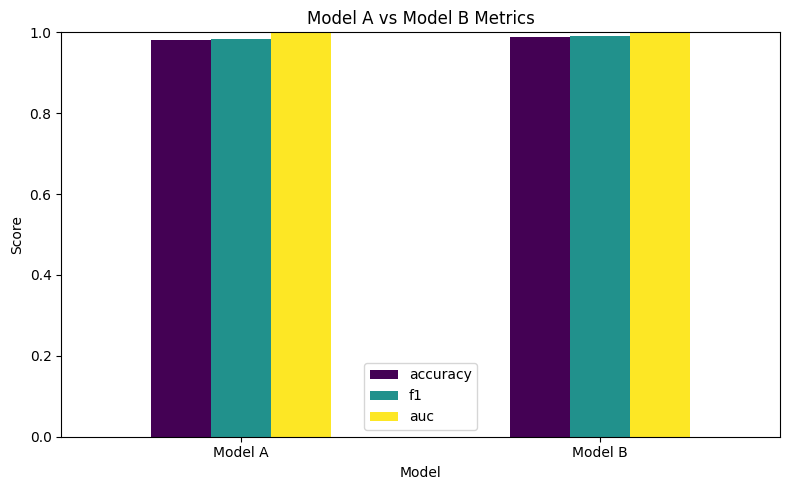

,best_model,best_score
accuracy,Model B,0.988660
f1,Model B,0.989899
auc,Model A,0.999455


In [6]:
plot_df = comp_df[["accuracy", "f1", "auc"]].apply(pd.to_numeric, errors="coerce")
plot_df

axis = plot_df.plot(kind="bar", figsize=(8, 5), ylim=(0.0, 1.0), colormap="viridis")
axis.set_title("Model A vs Model B Metrics")
axis.set_ylabel("Score")
axis.set_xlabel("Model")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

best_df = pd.DataFrame({"best_model": plot_df.idxmax(), "best_score": plot_df.max()})
best_df